In [1]:
!apt-get install tesseract-ocr -y

!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [2]:
import cv2
import pytesseract

try:
    tesseract_version = pytesseract.get_tesseract_version()
    print(f"✅ Success! Tesseract OCR is installed. Version: {tesseract_version}")
    print(f"✅ OpenCV Version: {cv2.__version__}")
except pytesseract.TesseractNotFoundError:
    print("❌ Tesseract is not found. Please re-run the installation cell above.")

✅ Success! Tesseract OCR is installed. Version: 4.1.1
✅ OpenCV Version: 4.13.0


# **Visual Confirmation**

--- 1. Pre-Processed (Adaptive Binarization) Optic Feed ---


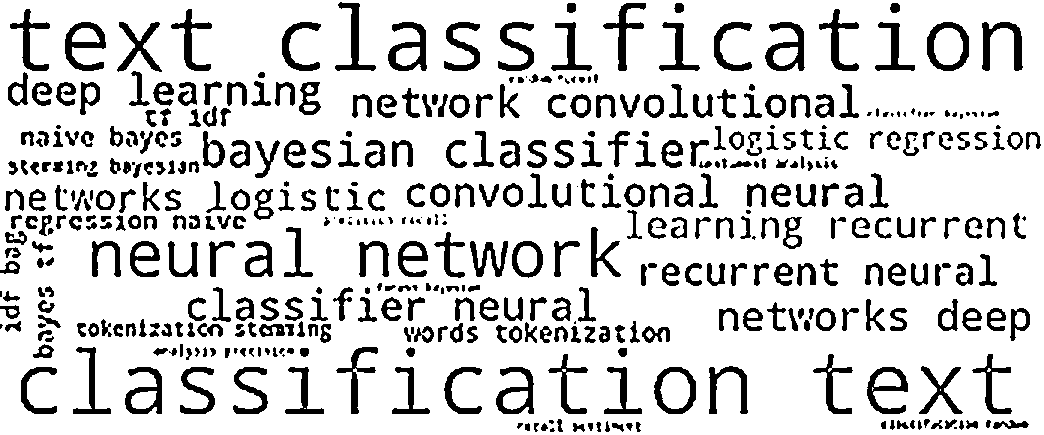

In [3]:
from google.colab.patches import cv2_imshow

image = cv2.imread("/content/download.png")

if image is None:
    print("Error: Image not found. Please check your filename.")
else:
    # --- PHASE 1: MATRIX SCALING ---
    # Bring back the upscaler so the engine can read the tiny words
    scale_factor = 3
    width = int(image.shape[1] * scale_factor)
    height = int(image.shape[0] * scale_factor)
    resized_image = cv2.resize(image, (width, height), interpolation=cv2.INTER_CUBIC)

    # --- PHASE 2: SYSTEMATIC PRE-PROCESSING ---
    gray = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # THE UPGRADE: Adaptive Thresholding
    # cv2.ADAPTIVE_THRESH_GAUSSIAN_C calculates localized thresholds to rescue light text.
    # 15 is the block size (neighborhood), and 5 is the constant subtracted from the mean.
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 5)

    print("--- 1. Pre-Processed (Adaptive Binarization) Optic Feed ---")
    # You will notice the light yellow words are now solid black!
    cv2_imshow(thresh)

# **OCR ENGINE & 80% GATEKEEPER FILTER**

In [4]:
from PIL import Image

# --- PHASE 3: OCR ENGINE ---
    # PSM 11 is perfect for hunting down scattered text
custom_config = r'--psm 11 --dpi 300'

    # Pass the OpenCV array directly
data = pytesseract.image_to_data(thresh, config=custom_config, output_type=pytesseract.Output.DICT)

    # --- PHASE 4: THE 80% GATEKEEPER ---
print("\n--- 2. Final Validated Output (Confidence >= 80%) ---")
extracted_words = []

for i in range(len(data['text'])):
    word = data['text'][i].strip()
    confidence = int(data['conf'][i])

        # Filter for non-empty, high-confidence strings
    if word != "" and confidence >= 80:
          print(f"Confidence: {confidence}% | Word: '{word}'")
          extracted_words.append(word)

print("\n--- Reconstructed Clean String ---")
print(" ".join(extracted_words))


--- 2. Final Validated Output (Confidence >= 80%) ---
Confidence: 93% | Word: 'classification'
Confidence: 96% | Word: 'deep'
Confidence: 96% | Word: 'learning'
Confidence: 96% | Word: 'network'
Confidence: 92% | Word: 'convolutional...'
Confidence: 95% | Word: 'naive'
Confidence: 96% | Word: 'bayesian'
Confidence: 92% | Word: 'classifie'
Confidence: 96% | Word: 'networks'
Confidence: 92% | Word: 'logistic'
Confidence: 88% | Word: '¢'
Confidence: 96% | Word: 'convolutional'
Confidence: 96% | Word: 'neural'
Confidence: 94% | Word: 'neural'
Confidence: 94% | Word: 'network'
Confidence: 96% | Word: 'learning'
Confidence: 95% | Word: 'recurrent'
Confidence: 96% | Word: 'recurrent'
Confidence: 96% | Word: 'neural'
Confidence: 91% | Word: 'assifier'
Confidence: 96% | Word: 'ne'
Confidence: 86% | Word: 'tokenization'
Confidence: 96% | Word: 'networks'
Confidence: 96% | Word: 'deep'
Confidence: 95% | Word: 'fication'
Confidence: 96% | Word: 'text'

--- Reconstructed Clean String ---
classific